In [ ]:
# Imports & Configuration

import os
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm

## Paths
RAW_IMG_DIR = Path("../dataset/train/images")
RAW_LBL_DIR = Path("../dataset/train/labels")
SPLIT_BASE  = Path("../dataset/split")
YAML_OUT    = Path("../dataset/data_split.yaml")

## Split ratios
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
RANDOM_SEED  = 42

## Class names (matches dataset/data.yaml exactly; index 0 = '0'/Unknown)
CLASS_NAMES = [
    "0",          # class 0  (labelled '0' in data.yaml)
    "Crack",
    "Dead_Knot",
    "Healthy",
    "Knot_missing",     # trailing space stripped from data.yaml
    "Knot_with_crack",
    "Live_Knot",
    "Marrow",
    "Quartzity",
    "Resin",
]

print(f"RAW_IMG_DIR : {RAW_IMG_DIR.resolve()}")
print(f"SPLIT_BASE  : {SPLIT_BASE.resolve()}")
print(f"Classes     : {len(CLASS_NAMES)}")


RAW_IMG_DIR : C:\repositories\dip\dip_assignment\dataset\train\images
SPLIT_BASE  : C:\repositories\dip\dip_assignment\dataset\split
Classes     : 10


In [2]:
# Helper Functions

def load_image(path):
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img


def load_labels(label_path):
    labels = []
    label_path = Path(label_path)
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                labels.append([int(parts[0])] + [float(v) for v in parts[1:5]])
    return labels


def save_image(img, filename, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_dir / filename), img)


def save_labels(labels, filename, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    with open(output_dir / filename, "w") as f:
        for row in labels:
            f.write(f"{int(row[0])} {row[1]:.6f} {row[2]:.6f} {row[3]:.6f} {row[4]:.6f}\n")


def draw_bboxes(img, labels, class_names):
    out = img.copy()
    h, w = out.shape[:2]
    for cls_id, cx, cy, bw, bh in labels:
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
        cv2.putText(out, label, (x1, max(y1 - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

In [3]:
# Augmentation Functions

##     Transform YOLO labels after a rotation described by affine matrix M.
def rotate_yolo_labels(labels, M, img_w, img_h):
    new_labels = []
    for cls_id, cx, cy, bw, bh in labels:
        # Normalised YOLO -> 4 image-space corners (x, y)
        x_c = cx * img_w
        y_c = cy * img_h
        hw  = bw * img_w / 2
        hh  = bh * img_h / 2
        corners = np.array([
            [x_c - hw, y_c - hh],
            [x_c + hw, y_c - hh],
            [x_c + hw, y_c + hh],
            [x_c - hw, y_c + hh],
        ], dtype=np.float32)

        # Apply the 2x3 affine matrix
        ones    = np.ones((4, 1), dtype=np.float32)
        coords  = np.hstack([corners, ones])   # (4, 3)
        rotated = (M @ coords.T).T             # (4, 2)

        # Axis-aligned bounding box from rotated corners
        x_min = rotated[:, 0].min()
        x_max = rotated[:, 0].max()
        y_min = rotated[:, 1].min()
        y_max = rotated[:, 1].max()

        # Clip to image boundaries
        x_min = max(0.0, x_min)
        y_min = max(0.0, y_min)
        x_max = min(float(img_w), x_max)
        y_max = min(float(img_h), y_max)

        new_bw = (x_max - x_min) / img_w
        new_bh = (y_max - y_min) / img_h

        # Drop degenerate boxes
        if new_bw < 0.02 or new_bh < 0.02:
            continue

        new_cx = (x_min + x_max) / 2 / img_w
        new_cy = (y_min + y_max) / 2 / img_h
        new_labels.append([cls_id, new_cx, new_cy, new_bw, new_bh])

    return new_labels

##     Generate 6 augmented variants of (img, labels).
def augment_image(img, labels):
    h, w = img.shape[:2]
    variants = []

    # 1. Horizontal flip
    hflip_img = cv2.flip(img, 1)
    hflip_lbl = [[c, 1.0 - cx, cy, bw, bh] for c, cx, cy, bw, bh in labels]
    variants.append((hflip_img, hflip_lbl, "hflip"))

    # 2. Vertical flip
    vflip_img = cv2.flip(img, 0)
    vflip_lbl = [[c, cx, 1.0 - cy, bw, bh] for c, cx, cy, bw, bh in labels]
    variants.append((vflip_img, vflip_lbl, "vflip"))

    # 3. Rotation +15°
    M_pos = cv2.getRotationMatrix2D((w / 2, h / 2), 15, 1.0)
    rot_pos_img = cv2.warpAffine(img, M_pos, (w, h),
                                  borderMode=cv2.BORDER_REFLECT_101)
    rot_pos_lbl = rotate_yolo_labels(labels, M_pos, w, h)
    variants.append((rot_pos_img, rot_pos_lbl, "rot_pos"))

    # 4. Rotation −15°
    M_neg = cv2.getRotationMatrix2D((w / 2, h / 2), -15, 1.0)
    rot_neg_img = cv2.warpAffine(img, M_neg, (w, h),
                                  borderMode=cv2.BORDER_REFLECT_101)
    rot_neg_lbl = rotate_yolo_labels(labels, M_neg, w, h)
    variants.append((rot_neg_img, rot_neg_lbl, "rot_neg"))

    # 5. Brightness boost
    bright_img = cv2.convertScaleAbs(img, alpha=1.2, beta=30)
    variants.append((bright_img, [row[:] for row in labels], "bright"))

    # 6. Brightness dim
    dim_img = cv2.convertScaleAbs(img, alpha=0.85, beta=-20)
    variants.append((dim_img, [row[:] for row in labels], "dim"))

    return variants


In [4]:
# Split Dataset

image_paths = sorted(RAW_IMG_DIR.glob("*.jpg")) + sorted(RAW_IMG_DIR.glob("*.png"))
n_total = len(image_paths)
assert n_total > 0, f"No images found in {RAW_IMG_DIR}"

## Shuffle with fixed seed for reproducibility
rng = random.Random(RANDOM_SEED)
shuffled = image_paths[:]
rng.shuffle(shuffled)

n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
# Test gets the remainder so counts always sum exactly to n_total
n_test  = n_total - n_train - n_val

train_paths = shuffled[:n_train]
val_paths   = shuffled[n_train : n_train + n_val]
test_paths  = shuffled[n_train + n_val :]

print(f"Total images : {n_total}")
print(f"Train        : {len(train_paths)}  ({len(train_paths)/n_total*100:.1f}%)")
print(f"Val          : {len(val_paths)}   ({len(val_paths)/n_total*100:.1f}%)")
print(f"Test         : {len(test_paths)}   ({len(test_paths)/n_total*100:.1f}%)")

# Output directories
for split in ("train", "valid", "test"):
    (SPLIT_BASE / split / "images").mkdir(parents=True, exist_ok=True)
    (SPLIT_BASE / split / "labels").mkdir(parents=True, exist_ok=True)

print(f"\nOutput directories created under {SPLIT_BASE.resolve()}")

Total images : 4177
Train        : 2923  (70.0%)
Val          : 626   (15.0%)
Test         : 628   (15.0%)

Output directories created under C:\repositories\dip\dip_assignment\dataset\split


In [5]:
# Augment Training Split
## Each raw training image produces 7 augmented variants:
## orig, hflip, vflip, rot_pos, rot_neg, bright, dim

TRAIN_IMG_OUT = SPLIT_BASE / "train" / "images"
TRAIN_LBL_OUT = SPLIT_BASE / "train" / "labels"

skipped_no_image = 0

for img_path in tqdm(train_paths, desc="Train augmentation"):
    lbl_path = RAW_LBL_DIR / (img_path.stem + ".txt")
    stem     = img_path.stem
    ext      = img_path.suffix  # e.g. .jpg

    try:
        img    = load_image(img_path)
        labels = load_labels(lbl_path)
    except FileNotFoundError:
        skipped_no_image += 1
        continue

    # Original + 6 augmented variants
    all_variants = [(img, labels, "orig")] + augment_image(img, labels)

    for aug_img, aug_labels, suffix in all_variants:
        out_name = f"{stem}_aug_{suffix}{ext}"
        save_image(aug_img, out_name, TRAIN_IMG_OUT)
        save_labels(aug_labels, f"{stem}_aug_{suffix}.txt", TRAIN_LBL_OUT)

train_img_count = len(list(TRAIN_IMG_OUT.glob("*")))
print(f"\nTraining images written : {train_img_count}")
print(f"Augmentation multiplier : {train_img_count / len(train_paths):.1f}x")
if skipped_no_image:
    print(f"Skipped (load error)    : {skipped_no_image}")

Train augmentation: 100%|██████████| 2923/2923 [14:31<00:00,  3.35it/s]



Training images written : 20461
Augmentation multiplier : 7.0x


In [6]:
# Copy Val & Test Splits (no augmentation)

def copy_split(paths, split_name):
    img_out = SPLIT_BASE / split_name / "images"
    lbl_out = SPLIT_BASE / split_name / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    for img_path in tqdm(paths, desc=f"{split_name} copy"):
        lbl_path = RAW_LBL_DIR / (img_path.stem + ".txt")
        shutil.copy2(img_path, img_out / img_path.name)
        if lbl_path.exists():
            shutil.copy2(lbl_path, lbl_out / lbl_path.name)
    count = len(list(img_out.glob("*")))
    print(f"  {split_name:6s} images copied : {count}")
    return count

copy_split(val_paths, "valid")
copy_split(test_paths, "test")


valid copy: 100%|██████████| 626/626 [00:04<00:00, 130.42it/s]


  valid  images copied : 626


test copy: 100%|██████████| 628/628 [00:05<00:00, 123.18it/s]

  test   images copied : 628


628

In [ ]:
# Write data_split.yaml

## Paths are relative to the yaml file location (dataset/data_split.yaml)
split_yaml = {
    "train": "split/train/images",
    "val"  : "split/valid/images",
    "test" : "split/test/images",
    "nc"   : len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(YAML_OUT, "w") as f:
    yaml.dump(split_yaml, f, default_flow_style=False, allow_unicode=True)

print(f"Written: {YAML_OUT.resolve()}")
print()
with open(YAML_OUT) as f:
    print(f.read())


Written: C:\repositories\dip\dip_assignment\dataset\data_split.yaml

names:
- Unknown
- Crack
- Dead_Knot
- Healthy
- Knot_missing
- Knot_with_crack
- Live_Knot
- Marrow
- Quartzity
- Resin
nc: 10
test: split/test/images
train: split/train/images
val: split/valid/images



── Split summary ──────────────────────────────
  Raw total          : 4177
  Train images       : 20461  (4.9x multiplier)
  Val   images       : 626
  Test  images       : 628
  _aug_ files in val : 0  (should be 0)
  _aug_ files in test: 0  (should be 0)


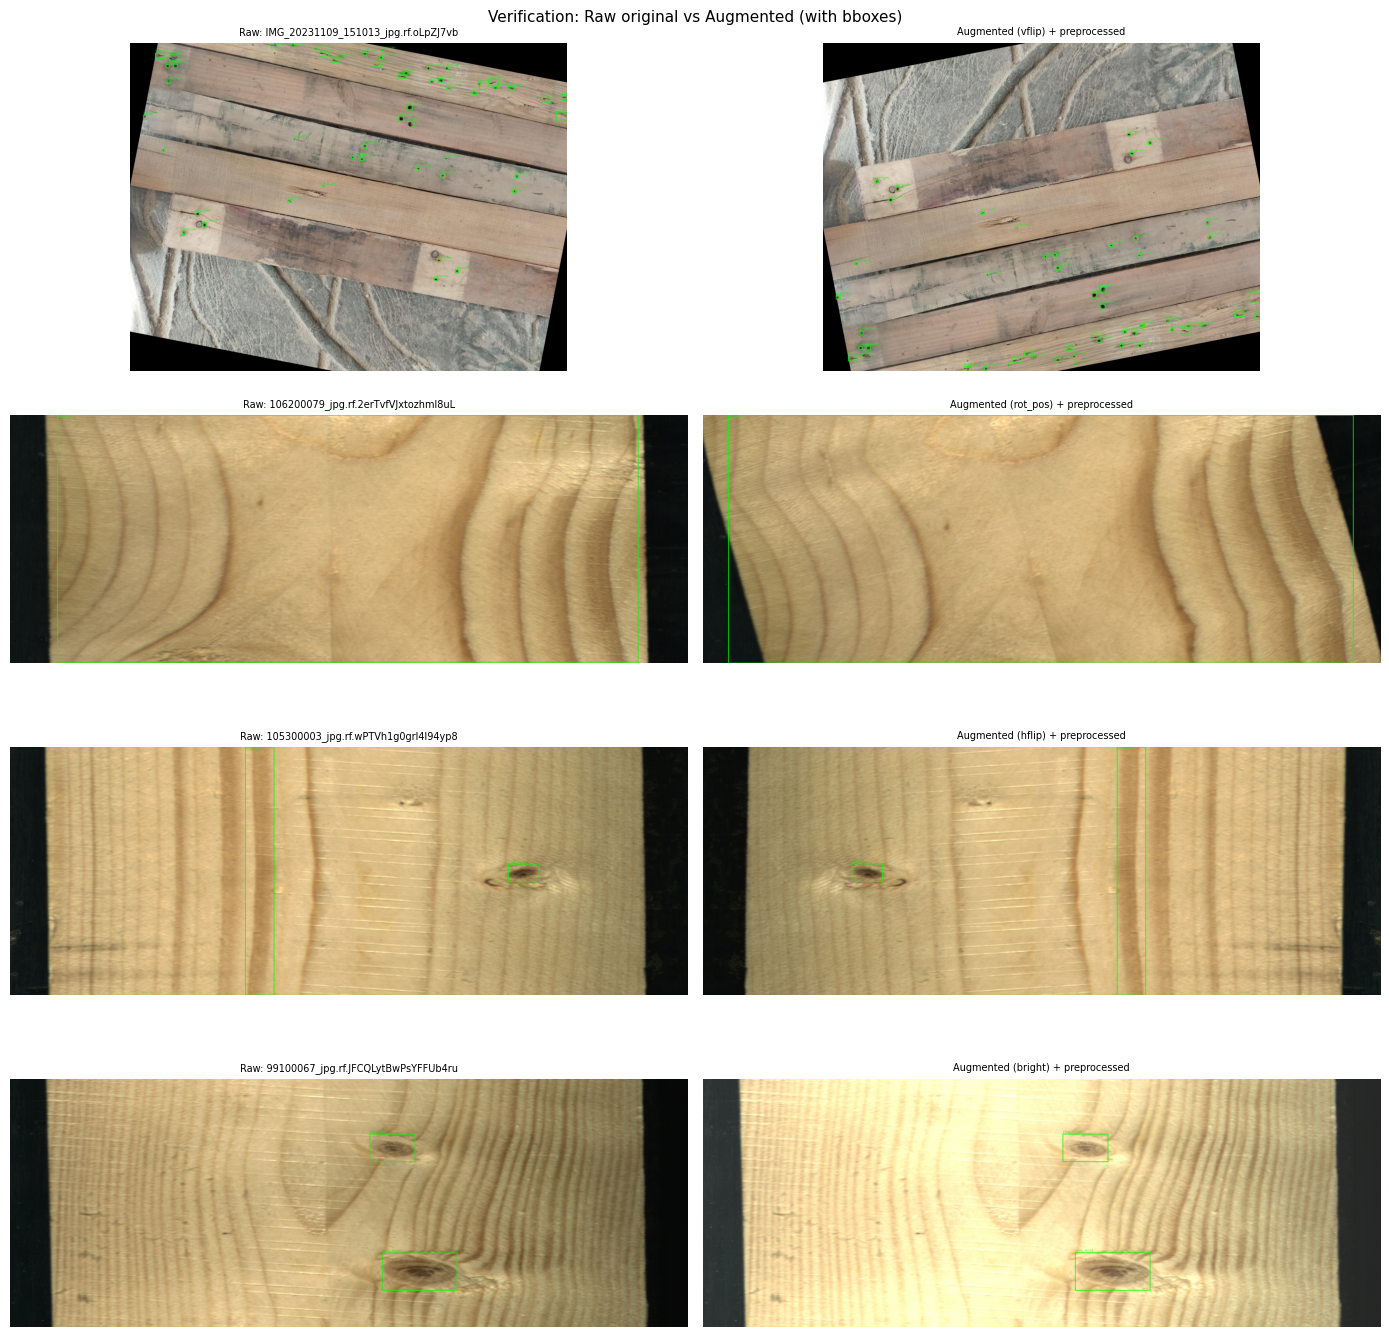

In [8]:
# Verification

train_imgs = sorted((SPLIT_BASE / "train" / "images").glob("*.jpg"))
val_imgs   = sorted((SPLIT_BASE / "valid" / "images").glob("*.jpg"))
test_imgs  = sorted((SPLIT_BASE / "test"  / "images").glob("*.jpg"))

print("── Split summary ──────────────────────────────")
print(f"  Raw total          : {n_total}")
print(f"  Train images       : {len(train_imgs)}  ({len(train_imgs)/n_total:.1f}x multiplier)")
print(f"  Val   images       : {len(val_imgs)}")
print(f"  Test  images       : {len(test_imgs)}")

aug_in_val  = [p for p in val_imgs  if "_aug_" in p.name]
aug_in_test = [p for p in test_imgs if "_aug_" in p.name]
print(f"  _aug_ files in val : {len(aug_in_val)}  (should be 0)")
print(f"  _aug_ files in test: {len(aug_in_test)}  (should be 0)")

# ── Visual check: 4 random training pairs (raw original vs augmented variant) ─
aug_variants = [p for p in train_imgs if "_aug_" in p.name and not p.stem.endswith("_aug_orig")]

sample_aug = random.sample(aug_variants, min(4, len(aug_variants)))
n_show     = len(sample_aug)

fig, axes = plt.subplots(n_show, 2, figsize=(14, n_show * 3.5))
if n_show == 1:
    axes = [axes]

for row, aug_path in enumerate(sample_aug):
    stem_parts = aug_path.stem.rsplit("_aug_", 1)  # ['original_stem', 'suffix']
    orig_stem  = stem_parts[0]
    suffix     = stem_parts[1] if len(stem_parts) > 1 else ""

    orig_path = RAW_IMG_DIR / (orig_stem + aug_path.suffix)
    lbl_path  = SPLIT_BASE / "train" / "labels" / (aug_path.stem + ".txt")

    orig_img = load_image(orig_path) if orig_path.exists() else np.zeros((100, 100, 3), dtype=np.uint8)
    aug_img  = load_image(aug_path)
    labels   = load_labels(lbl_path)

    orig_ann = draw_bboxes(orig_img, load_labels(RAW_LBL_DIR / (orig_stem + ".txt")), CLASS_NAMES)
    aug_ann  = draw_bboxes(aug_img, labels, CLASS_NAMES)

    axes[row][0].imshow(orig_ann)
    axes[row][0].set_title(f"Raw: {orig_stem[:35]}", fontsize=7)
    axes[row][0].axis("off")

    axes[row][1].imshow(aug_ann)
    axes[row][1].set_title(f"Augmented ({suffix}) + preprocessed", fontsize=7)
    axes[row][1].axis("off")

plt.suptitle("Verification: Raw original vs Augmented (with bboxes)", fontsize=11)
plt.tight_layout()
plt.show()